# Выравнивание

In [1]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from utils import detect_and_align, alignment_error


def show_alignment(photo_path, meta, save=True):
    photo = cv2.imread(photo_path)
    res = detect_and_align(photo_path, meta)
    err, _ = alignment_error(res["aligned"], meta)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(photo, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Фото — {Path(photo_path).stem}")
    axes[1].imshow(cv2.cvtColor(res["aligned"], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f"Выровненное — ошибка {err:.1f} px")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    if save:
        stem = Path(photo_path).stem
        cv2.imwrite(f"output/{stem}_aligned.jpg", res["aligned"])

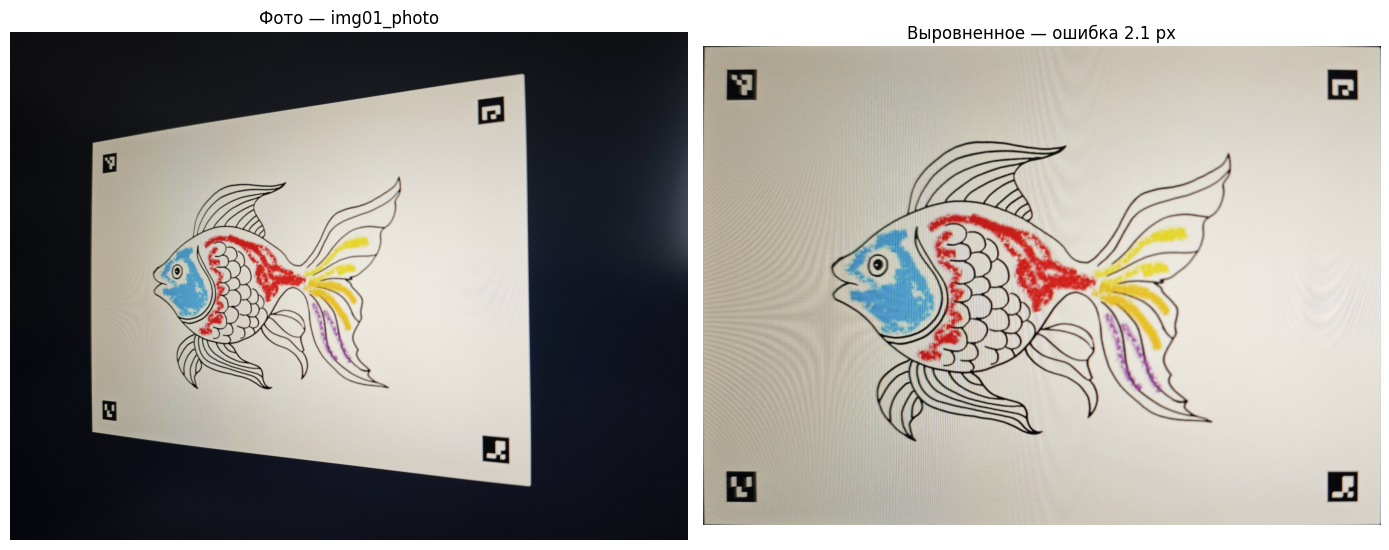

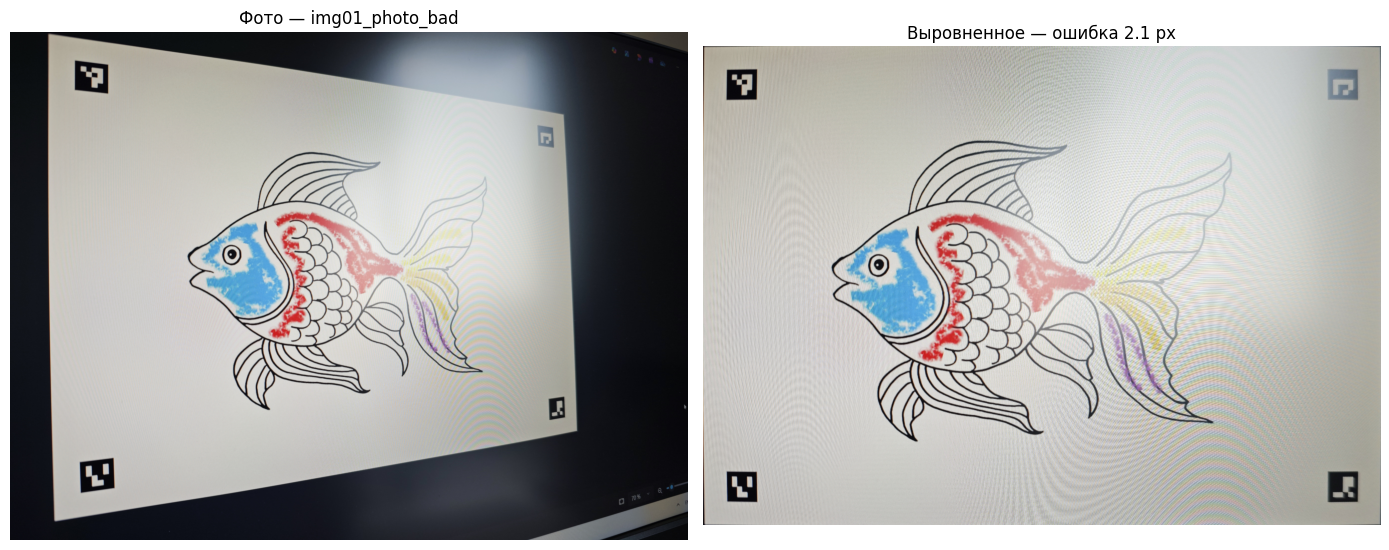

In [2]:
meta_img01 = json.load(open("output/img01_raw_meta.json"))
show_alignment("input/img01_photo.jpg", meta_img01)
show_alignment("input/img01_photo_bad.jpg", meta_img01)

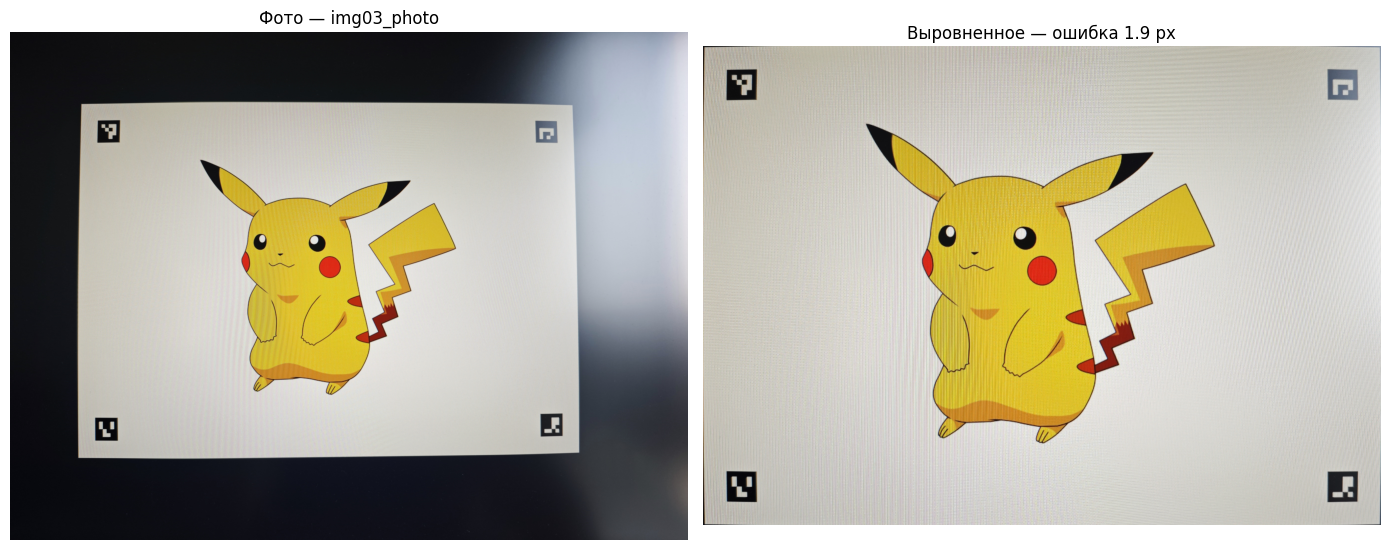

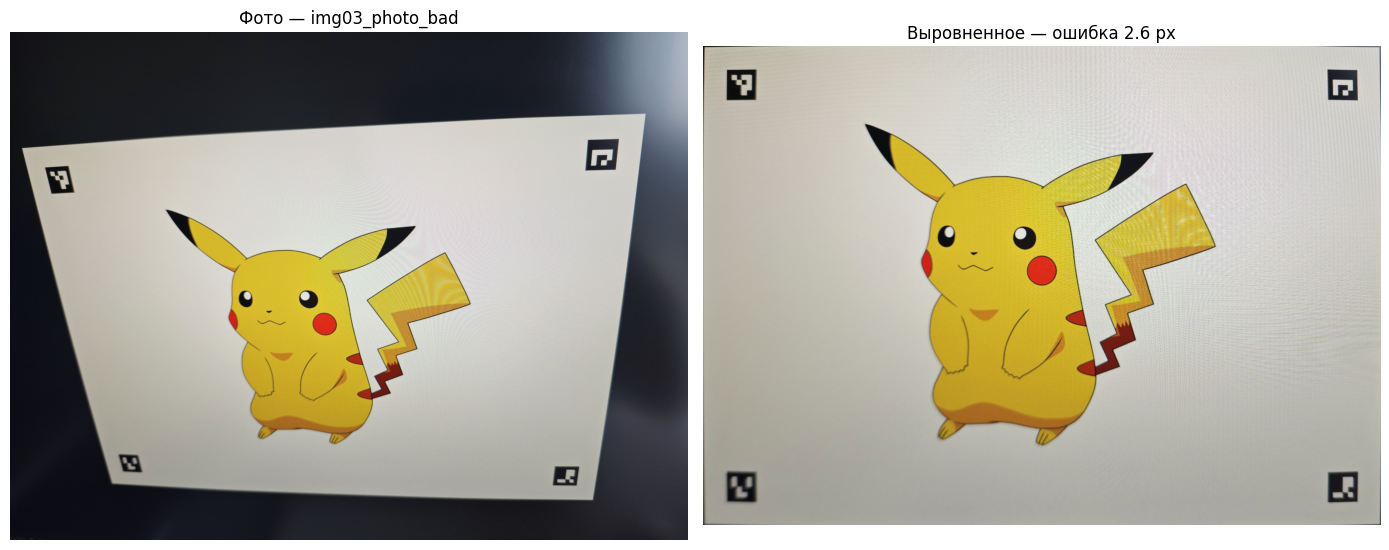

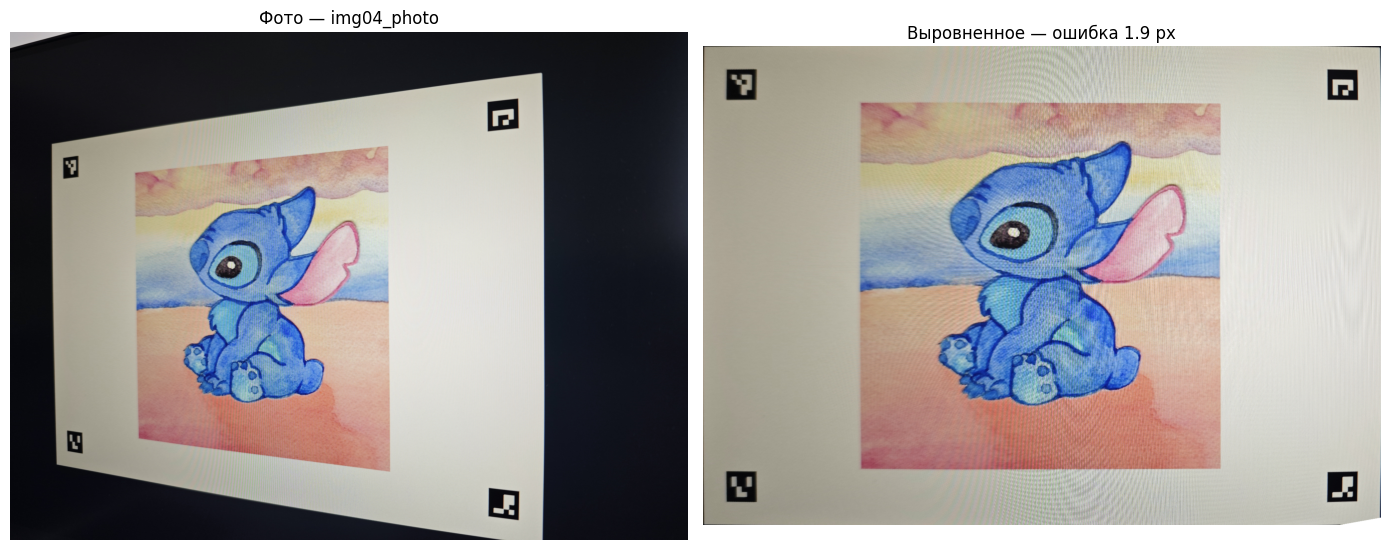

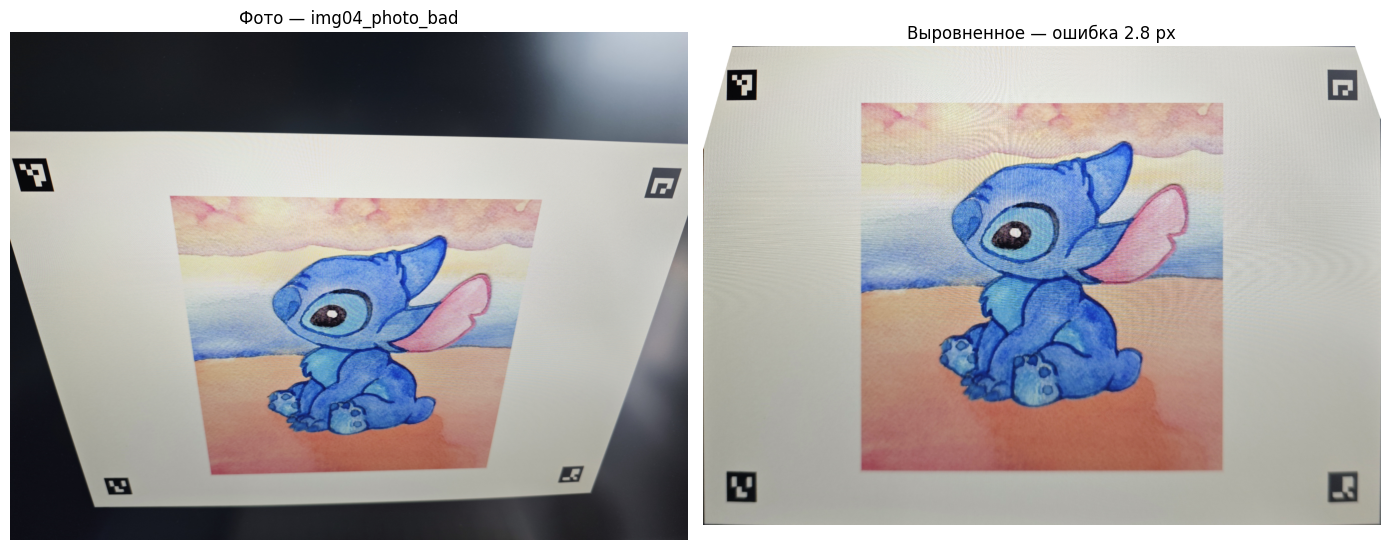

In [3]:
meta_blank = json.load(open("output/blank_meta.json"))
show_alignment("input/img03_photo.jpg", meta_blank)
show_alignment("input/img03_photo_bad.jpg", meta_blank)
show_alignment("input/img04_photo.jpg", meta_blank)
show_alignment("input/img04_photo_bad.jpg", meta_blank)